Text(0.5, 0.92, 'Lorenz')

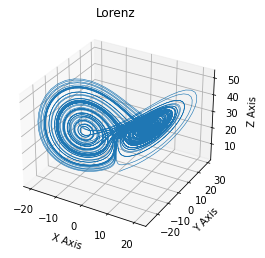

In [6]:
#Generating Lorenz Time Series 

import numpy as np
import matplotlib.pyplot as plt


# Lorenz system dynamics
def lorenz(xyz, *, s=10, r=28, b=2.667):
    x, y, z = xyz
    x_dot = s*(y - x)
    y_dot = r*x - y - x*z
    z_dot = x*y - b*z
    return np.array([x_dot, y_dot, z_dot])

# Simulation parameters
dt = 0.01
num_steps = 10000
xyzs = np.empty((num_steps + 1, 3))
xyzs[0] = (1, 1, 1)  # initial state

# Numerical integration (Euler method)
for i in range(num_steps):
    xyzs[i + 1] = xyzs[i] + lorenz(xyzs[i]) * dt

# Extract 1D series (x component only)
x_series = xyzs[:, 0]

# Function to add noise at a given SNR (dB)
def add_noise(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db/10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), signal.shape)
    return signal + noise

# Noisy versions
x_clean = x_series
x_noisy_3dB = add_noise(x_series, 3)
x_noisy_10dB = add_noise(x_series, 10)

# Plot
ax = plt.figure().add_subplot(projection='3d')

ax.plot(*xyzs.T, lw=0.6)
ax.set_xlabel("X Axis")
ax.set_ylabel("Y Axis")
ax.set_zlabel("Z Axis")
ax.set_title("Lorenz")

In [5]:
#Creating Supervised Data

def create_supervised(series, D=10, L=1):
    """
    Turn a time series into supervised learning data.
    Input X = [s(n), s(n+1), ..., s(n+D-1)]
    Output y = s(n+D-1+L)
    """
    X, y = [], []
    for i in range(len(series) - D - L + 1):
        X.append(series[i:i+D])
        y.append(series[i+D-1+L])
    return np.array(X), np.array(y)

# Parameters
D = 10  # window size
L_short = 1  # short-term prediction (next step)
L_long = 10 # long-term prediction

# Example: create supervised dataset for clean signal
X_clean_short, y_clean_short = create_supervised(x_clean, D, L_short)
X_clean_long, y_clean_long = create_supervised(x_clean, D, L_long)

# Split into train/test
def split_data(X, y, train_ratio=0.7):
    split_idx = int(len(X) * train_ratio)
    return (X[:split_idx], y[:split_idx],
            X[split_idx:], y[split_idx:])

Xtr_clean, ytr_clean, Xte_clean, yte_clean = split_data(X_clean_short, y_clean_short)


In [3]:
#Training Models (Linear, MLP, SVR, GPR)

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.metrics import mean_squared_error

def evaluate_models(X_train, y_train, X_test, y_test):
    results = {}

    # --- Linear Regression ---
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    results["Linear Regression"] = mean_squared_error(y_test, y_pred)

    # --- MLP Neural Network ---
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=0)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    results["MLP Neural Network"] = mean_squared_error(y_test, y_pred)

    # --- RBF Kernel SVR (like nonlinear regression) ---
    svr = SVR(kernel="rbf")
    svr.fit(X_train, y_train)
    y_pred = svr.predict(X_test)
    results["RBF SVR"] = mean_squared_error(y_test, y_pred)

    # --- Gaussian Process Regression ---
    gpr = GaussianProcessRegressor(kernel=RBF(), alpha=1e-3)
    gpr.fit(X_train, y_train)
    y_pred = gpr.predict(X_test)
    results["Gaussian Process"] = mean_squared_error(y_test, y_pred)

    return results


In [ ]:
#Comparison

datasets = {
    "Clean": x_clean,
    "Noisy 3dB": x_noisy_3dB,
    "Noisy 10dB": x_noisy_10dB
}

all_results = {}

for name, series in datasets.items():
    X, y = create_supervised(series, D, L_short)  # short-term prediction
    Xtr, ytr, Xte, yte = split_data(X, y)
    results = evaluate_models(Xtr, ytr, Xte, yte)
    all_results[name] = results